In [1]:
#Import and initialisation
import os
from glob import glob
from os import getcwd
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson
from scipy.stats import gamma

In [2]:
#Define parameters
numberOfSubSequences = 5000000

lengthofSubSequences = 3000 #ns
start_time_pulse = 1000 #ns
end_time_pulse = 2000 #ns
sampleGaps = 5 #ns
photonsperSubSequences = 4

In [3]:
#Preparation
numberOfTicks = int(lengthofSubSequences/sampleGaps)
numberOfTicksinPulse = int((end_time_pulse - start_time_pulse) /sampleGaps)
start_Ticks_pulse = int(start_time_pulse/sampleGaps)
end_Ticks_pulse = int(end_time_pulse/sampleGaps)

print(f'number Of Ticks per SubSequence : {numberOfTicks}')
print(f'start_Ticks_pulse : {start_Ticks_pulse}')
print(f'end_Ticks_pulse : {end_Ticks_pulse}')
print(f'Number Of Ticks in a Pulse : {numberOfTicksinPulse}')

data_list = []

number Of Ticks per SubSequence : 600
start_Ticks_pulse : 200
end_Ticks_pulse : 400
Number Of Ticks in a Pulse : 200


In [4]:
#Defining the p relation with time
def prob_dis_pulse_rourec(i, photonsperSubSequences, numberOfTicksinPulse, start_Ticks_pulse, end_Ticks_pulse):
    # Your baseline probability calculation
    p_plain = photonsperSubSequences / numberOfTicksinPulse / 2
    
    # Find the midpoint of the pulse
    t_center = (start_Ticks_pulse + end_Ticks_pulse) / 2.0
    
    # Define how wide the pulse should be based on your start/end ticks
    width = (end_Ticks_pulse - start_Ticks_pulse) / 2.0
    
    # Calculate the Super-Gaussian envelope (using power of 6 for rounded corners)
    # The 0.8 scaling factor just keeps the edges nicely within your start/end ticks
    envelope = np.exp(-((i - t_center) / (width * 0.8)) ** 6)
    
    # Scale the envelope by your baseline probability
    prob_Of_Occasion = p_plain * envelope
    
    return prob_Of_Occasion

In [5]:
#def gamma
def prob_dis_pulse_gam(i, photonsperSubSequences, numberOfTicksinPulse, start_Ticks_pulse, end_Ticks_pulse):
    p_plain = photonsperSubSequences / numberOfTicksinPulse / 2
    i_inpulse = i - start_Ticks_pulse
    
    # The 'scale' acts as a stretching multiplier. 
    # Increase this number (e.g., 10, 20, 50) to make the pulse wider.
    stretch_factor = 15 
    
    envelope = gamma.pdf(i_inpulse, a=4, scale=stretch_factor)
    
    # Normalize the curve so the peak probability matches your p_plain baseline
    peak_x = (4 - 1) * stretch_factor  # Mathematical peak of this specific gamma curve
    peak_value = gamma.pdf(peak_x, a=4, scale=stretch_factor)
    
    prob_Of_Occasion = p_plain * (envelope / peak_value)
    
    return prob_Of_Occasion

In [6]:
#def tanh (sigmoid-edged flat top)
def prob_dis_pulse_tanh(i, photonsperSubSequences, numberOfTicksinPulse, start_Ticks_pulse, end_Ticks_pulse):
    p_plain = photonsperSubSequences / numberOfTicksinPulse / 2

    t_center = (start_Ticks_pulse + end_Ticks_pulse) / 2.0
    half_width = (end_Ticks_pulse - start_Ticks_pulse) / 2.0

    # 'sharpness' controls how steep the rising/falling edges are.
    # Larger = steeper walls, smaller = softer, more rounded shoulders.
    sharpness = 8.0

    rising_edge = 0.5 * (1 + np.tanh(sharpness * (i - (t_center - half_width * 0.8)) / half_width))
    falling_edge = 0.5 * (1 + np.tanh(sharpness * ((t_center + half_width * 0.8) - i) / half_width))

    envelope = rising_edge * falling_edge
    # Normalise so the flat-top plateau sits at 1.0
    envelope = envelope / envelope.max()

    prob_Of_Occasion = p_plain * envelope
    return prob_Of_Occasion


#def trapezoid (linear ramp up/down, flat middle)
def prob_dis_pulse_trapz(i, photonsperSubSequences, numberOfTicksinPulse, start_Ticks_pulse, end_Ticks_pulse):
    p_plain = photonsperSubSequences / numberOfTicksinPulse / 2

    # Fraction of the pulse width given to each ramp (e.g. 0.15 = 15% rise, 15% fall, 70% flat)
    ramp_fraction = 0.15
    pulse_width = end_Ticks_pulse - start_Ticks_pulse
    ramp_width = pulse_width * ramp_fraction

    rise_end = start_Ticks_pulse + ramp_width
    fall_start = end_Ticks_pulse - ramp_width

    envelope = np.ones_like(i, dtype=float)
    envelope = np.where(i < rise_end, (i - start_Ticks_pulse) / ramp_width, envelope)
    envelope = np.where(i > fall_start, (end_Ticks_pulse - i) / ramp_width, envelope)
    envelope = np.clip(envelope, 0, 1)

    prob_Of_Occasion = p_plain * envelope
    return prob_Of_Occasion


#def Tukey window (cosine-tapered flat top)
def prob_dis_pulse_tukey(i, photonsperSubSequences, numberOfTicksinPulse, start_Ticks_pulse, end_Ticks_pulse):
    p_plain = photonsperSubSequences / numberOfTicksinPulse / 2

    pulse_width = end_Ticks_pulse - start_Ticks_pulse
    # alpha = fraction of the pulse that is tapered (0 = rectangular, 1 = full cosine/Hann)
    alpha = 0.3

    x = (i - start_Ticks_pulse) / pulse_width  # normalised position, 0 to 1
    envelope = np.ones_like(x, dtype=float)

    left_mask = x < alpha / 2
    right_mask = x > 1 - alpha / 2

    envelope = np.where(
        left_mask,
        0.5 * (1 + np.cos(np.pi * (2 * x / alpha - 1))),
        envelope
    )
    envelope = np.where(
        right_mask,
        0.5 * (1 + np.cos(np.pi * (2 * x / alpha - 2 / alpha + 1))),
        envelope
    )

    prob_Of_Occasion = p_plain * envelope
    return prob_Of_Occasion


#def super-Lorentzian (rounded flat top, heavier tails than super-Gaussian)
def prob_dis_pulse_lorentz(i, photonsperSubSequences, numberOfTicksinPulse, start_Ticks_pulse, end_Ticks_pulse):
    p_plain = photonsperSubSequences / numberOfTicksinPulse / 2

    t_center = (start_Ticks_pulse + end_Ticks_pulse) / 2.0
    width = (end_Ticks_pulse - start_Ticks_pulse) / 2.0

    # 'order' controls flat-top squareness, same role as the power-of-6 in the super-Gaussian
    order = 6

    envelope = 1.0 / (1.0 + ((i - t_center) / (width * 0.8)) ** order)

    prob_Of_Occasion = p_plain * envelope
    return prob_Of_Occasion


#def error-function flat top (smooth, symmetric, physically common for detector rise/fall)
def prob_dis_pulse_erf(i, photonsperSubSequences, numberOfTicksinPulse, start_Ticks_pulse, end_Ticks_pulse):
    from scipy.special import erf
    p_plain = photonsperSubSequences / numberOfTicksinPulse / 2

    # 'edge_sigma' sets how gradual the rise/fall is, analogous to a detector response time
    edge_sigma = (end_Ticks_pulse - start_Ticks_pulse) * 0.05

    rising_edge = 0.5 * (1 + erf((i - start_Ticks_pulse) / (edge_sigma * np.sqrt(2))))
    falling_edge = 0.5 * (1 + erf((end_Ticks_pulse - i) / (edge_sigma * np.sqrt(2))))

    envelope = rising_edge * falling_edge
    envelope = envelope / envelope.max()

    prob_Of_Occasion = p_plain * envelope
    return prob_Of_Occasion

In [7]:
# Run and generate the numpy array — vectorized version
# Build the per-tick probability array once (identical for every sub-sequence)
prob_array = np.full(numberOfTicks, 0.01 / numberOfTicks)

ticks_in_pulse = np.arange(start_Ticks_pulse, end_Ticks_pulse)
prob_array[start_Ticks_pulse:end_Ticks_pulse] = prob_dis_pulse_rourec(
    ticks_in_pulse, photonsperSubSequences, numberOfTicksinPulse,
    start_Ticks_pulse, end_Ticks_pulse
)

# Process sequences in chunks to keep memory bounded
chunk_size = 50000
data_chunks = []

for chunk_start in range(0, numberOfSubSequences, chunk_size):
    n = min(chunk_size, numberOfSubSequences - chunk_start)

    # One random draw per (sequence, tick, spad) in this chunk
    rand = np.random.random(size=(n, numberOfTicks, 2)).astype(np.float32)
    occurred = rand < prob_array[None, :, None]

    seq_idx, tick_idx, spad_idx = np.nonzero(occurred)
    seq_idx = seq_idx + chunk_start  # offset back to global sequence numbers

    chunk_data = np.column_stack([seq_idx, tick_idx * sampleGaps+1, spad_idx])
    data_chunks.append(chunk_data)

data = np.vstack(data_chunks)
print(f"Simulated {len(data)} photon events.")

Simulated 14898728 photon events.


In [8]:
#Setting and mask and tbin etc.
mask_start_t = 1100
mask_end_t = 1900

mask = (data[:, 1] >= mask_start_t) & (data[:, 1] <= mask_end_t)
masked_data = data[mask]

#Set tbin
tbin = 10


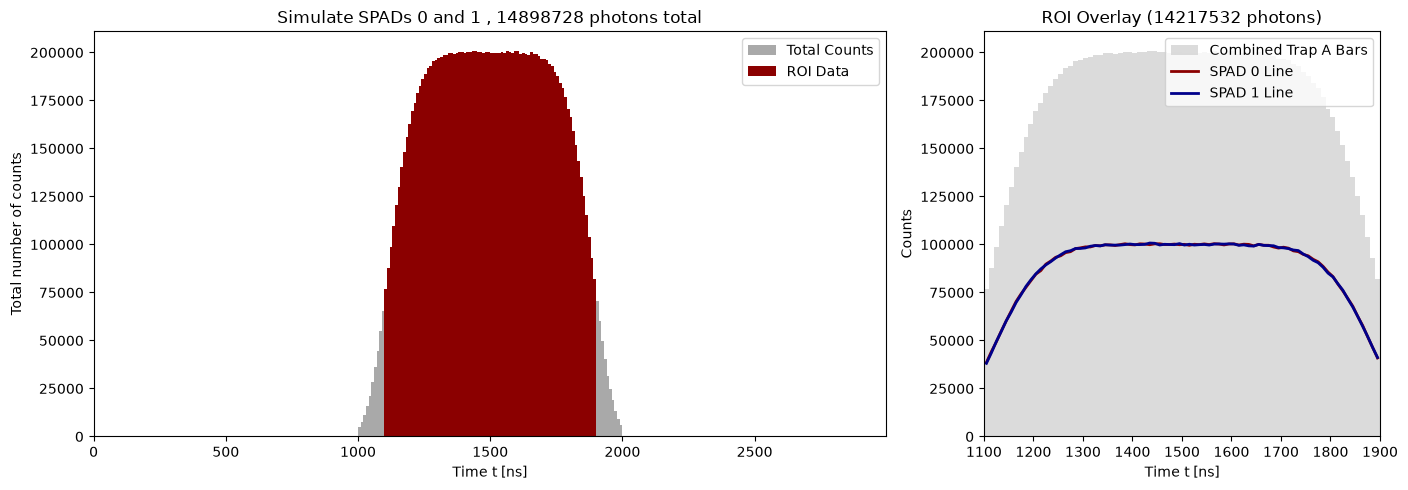

In [9]:
#Plot all photons and lines
time_spads = data[:, 1]
selectedtime_spads = masked_data[:,1]

# Separating times for each SPAD
time_spad0 = masked_data[masked_data[:, 2] == 0][:, 1]
time_spad1 = masked_data[masked_data[:, 2] == 1][:, 1]

# 2. Calculate bins and centres specifically for the Region of Interest zoomed plot
roi_bins = np.arange(mask_start_t, mask_end_t + tbin, tbin)
roi_bin_centers = (roi_bins[:-1] + roi_bins[1:]) / 2

# 3. Get the counts for the line graphs
counts_spad0, _ = np.histogram(time_spad0, bins=roi_bins)
counts_spad1, _ = np.histogram(time_spad1, bins=roi_bins)

# 4. Create the 1x2 figure
fig, ax1 = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios':[2, 1]})

# LEFT PLOT
ax1[0].hist(time_spads, bins=np.arange(0, max(mask_end_t, max(time_spads))+tbin, tbin), color='darkgray', fill=True, label='Total Counts')
ax1[0].hist(selectedtime_spads, bins=np.arange(0, max(mask_end_t, max(time_spads))+tbin, tbin), color='darkred', fill=True, label='ROI Data')

ax1[0].set_xlim([0, max(mask_end_t, max(time_spads))])
ax1[0].set_xlabel('Time t [ns]')
ax1[0].set_ylabel('Total number of counts')
ax1[0].set_title(f'Simulate SPADs 0 and 1 , {len(time_spads)} photons total')
ax1[0].legend()

# RIGHT PLOT
# Plot the combined bars in the background (made lighter grey so lines pop out)
ax1[1].hist(selectedtime_spads, bins=roi_bins, color='lightgray', fill=True, alpha=0.8, label='Combined Trap A Bars')

# Plot the individual SPAD lines on top
ax1[1].plot(roi_bin_centers, counts_spad0, color='darkred', linestyle='-', linewidth=2, label=f'SPAD 0 Line')
ax1[1].plot(roi_bin_centers, counts_spad1, color='darkblue', linestyle='-', linewidth=2, label=f'SPAD 1 Line')

ax1[1].set_xlim([mask_start_t, mask_end_t])
ax1[1].set_xlabel('Time t [ns]')
ax1[1].set_ylabel('Counts')
ax1[1].set_title(f'ROI Overlay ({len(selectedtime_spads)} photons)')
ax1[1].legend()

plt.tight_layout()
plt.show()

Total number of gaps: 4785560


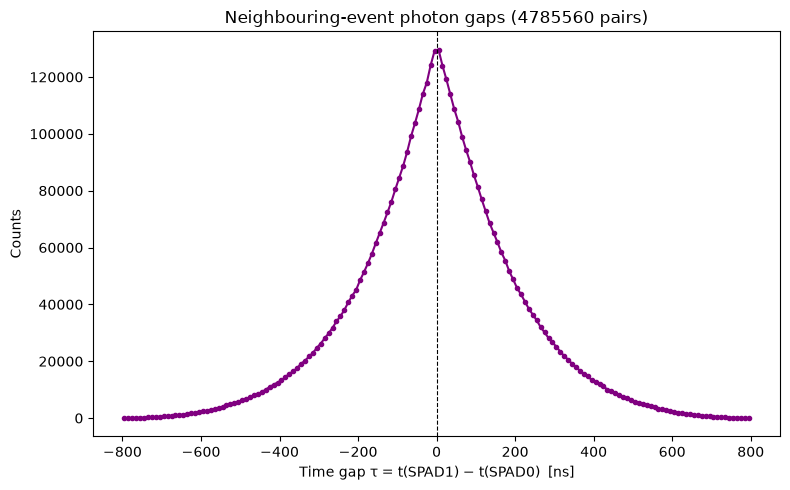

In [10]:
# Calculate time gaps between temporally NEIGHBOURING photons (adjacent in
# time, regardless of which SPAD fired first — but only counted when the
# pair is one SPAD0 and one SPAD1 event; same-SPAD adjacent pairs are skipped)
# gap = t(SPAD1) - t(SPAD0), sign preserved

# Sort once by (sequence, time) instead of re-filtering per sequence
order = np.lexsort((masked_data[:, 1], masked_data[:, 0]))
sorted_data = masked_data[order]

seq_ids = sorted_data[:, 0]
times = sorted_data[:, 1]
spads = sorted_data[:, 2]

# Valid neighbouring pair: same sequence, different SPAD
same_seq = seq_ids[:-1] == seq_ids[1:]
diff_spad = spads[:-1] != spads[1:]
valid = same_seq & diff_spad

t_a, t_b = times[:-1][valid], times[1:][valid]
spad_a = spads[:-1][valid]

gaps = np.where(spad_a == 1, t_a - t_b, t_b - t_a)
print(f"Total number of gaps: {len(gaps)}")

# --- Plotting Section ---
# Use tbin-width bins instead of a fixed bin COUNT, so bin width stays
# a clean multiple of sampleGaps and avoids aliasing against the
# discrete time grid the data actually lives on.
gap_min, gap_max = gaps.min(), gaps.max()
gap_bin_edges = np.arange(gap_min - tbin/2, gap_max + tbin, tbin)

counts, bin_edges = np.histogram(gaps, bins=gap_bin_edges)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

plt.figure(figsize=(8, 5))
plt.plot(bin_centers, counts, color='purple', marker='.', linestyle='-')
plt.axvline(0, color='k', linestyle='--', linewidth=0.8)
plt.xlabel('Time gap τ = t(SPAD1) − t(SPAD0)  [ns]')
plt.ylabel('Counts')
plt.title(f'Neighbouring-event photon gaps ({len(gaps)} pairs)')
plt.tight_layout()
plt.show()

Total single-photon-pair sequences: 593233
Expected Intersection with y axis: 8356.67 
Slop L: -11.69 


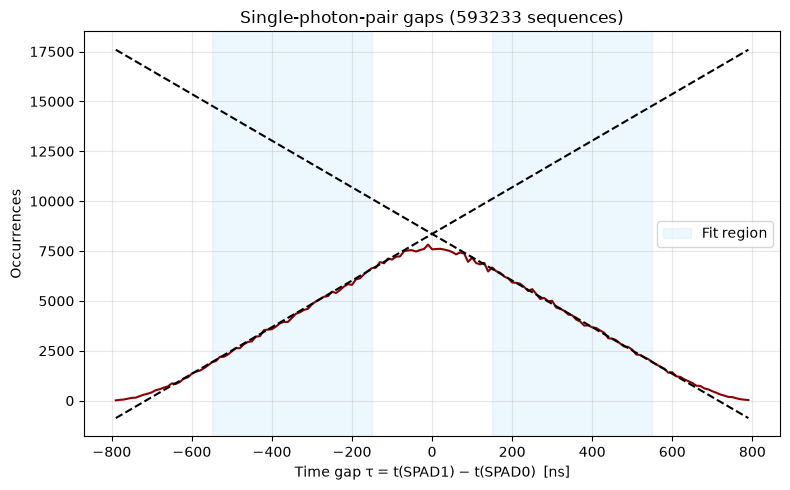

In [11]:
# Keep only sequences where SPAD0 fires exactly once AND SPAD1 fires exactly once
seq_ids = masked_data[:, 0]
spads = masked_data[:, 2]
times = masked_data[:, 1]

spad0_mask = spads == 0
spad1_mask = spads == 1

seq0, counts0 = np.unique(seq_ids[spad0_mask], return_counts=True)
seq1, counts1 = np.unique(seq_ids[spad1_mask], return_counts=True)

single0 = seq0[counts0 == 1]
single1 = seq1[counts1 == 1]

# Sequences with exactly one photon on each SPAD
valid_seqs = np.intersect1d(single0, single1)

# Build lookup: sequence -> time, restricted to the single-count sequences
seq_to_t0 = dict(zip(seq_ids[spad0_mask], times[spad0_mask]))
seq_to_t1 = dict(zip(seq_ids[spad1_mask], times[spad1_mask]))
# ^ safe because each valid_seqs key appears exactly once in each mask

t0_arr = np.array([seq_to_t0[s] for s in valid_seqs])
t1_arr = np.array([seq_to_t1[s] for s in valid_seqs])

gaps_single = t1_arr - t0_arr
abs_gaps_single = np.abs(gaps_single)

print(f"Total single-photon-pair sequences: {len(gaps_single)}")

max_gap = max(abs(gaps_single))
bins = np.arange(-max_gap, max_gap + tbin, tbin)
abs_bins = np.arange(0, max_gap + tbin, tbin)

bin_centers = (bins[:-1] + bins[1:]) / 2
abs_bin_centers = (abs_bins[:-1] + abs_bins[1:]) / 2

# Linear fit on both sides
sym_fit_s = 150
sym_fit_e = 550

# Compute the histogram counts
counts_single, _ = np.histogram(gaps_single, bins=bins)
abs_counts, _ = np.histogram(abs_gaps_single, abs_bins)

p_counts = gaps_single / len(gaps_single)

# Perform Linear Fit on the tails
abs_fit_mask = (abs_bin_centers > sym_fit_s) & (abs_bin_centers < sym_fit_e)

abs_tau = abs_bin_centers[abs_fit_mask]
abs_counts_fit = abs_counts[abs_fit_mask]
m, c = np.polyfit(abs_bin_centers[abs_fit_mask], abs_counts[abs_fit_mask], 1)
m = m / 2
c = c / 2
print(f"Expected Intersection with y axis: {c:.2f} ")
print(f"Slop L: {m:.2f} ")

plt.figure(figsize=(8, 5))
plt.plot(bin_centers, counts_single, color='darkred', marker='', linestyle='-')

envelopeR = m * bin_centers + c
envelopeL = -m * bin_centers + c
plt.plot(bin_centers, envelopeL, color='black', marker='', linestyle='--')
plt.plot(bin_centers, envelopeR, color='black', marker='', linestyle='--')
plt.axvspan(-sym_fit_e, -sym_fit_s, color='lightskyblue', alpha=0.15, label='Fit region')
plt.axvspan(sym_fit_s, sym_fit_e, color='lightskyblue', alpha=0.15)

plt.xlabel('Time gap τ = t(SPAD1) − t(SPAD0)  [ns]')
plt.ylabel('Occurrences')
plt.grid(axis='both', alpha=0.3)
plt.title(f'Single-photon-pair gaps ({len(gaps_single)} sequences)')
plt.legend()
plt.tight_layout()
plt.show()

Total photons used for normalisation: 593233000


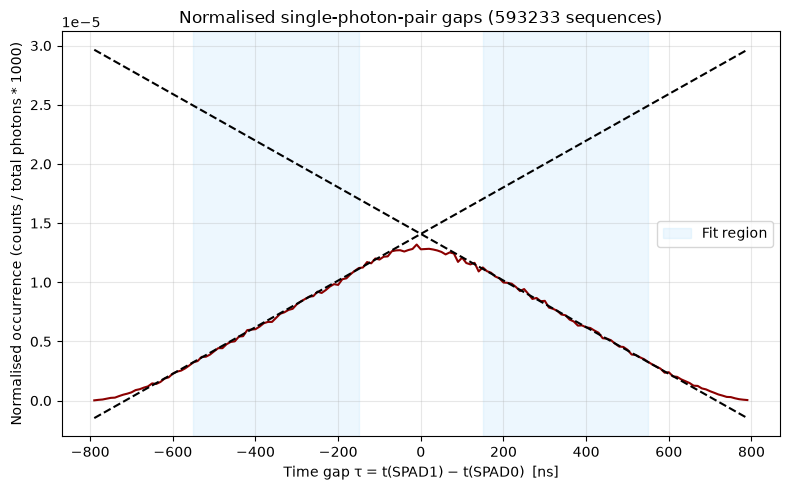

In [12]:
# --- Normalisation: divide bin occurrences by total photon count ---

# Total photons detected in this ROI (denominator for normalisation).
# Swap this for len(data) if you want to normalise against the full
# (unmasked) dataset instead of just the ROI-masked photons.
total_photons = np.sum(counts_single) * 1000


# Normalise the raw bin counts and the linear-fit envelope by the same factor
norm_counts_single = counts_single / total_photons
norm_envelopeL = envelopeL / total_photons
norm_envelopeR = envelopeR / total_photons

print(f"Total photons used for normalisation: {total_photons}")

plt.figure(figsize=(8, 5))
plt.plot(bin_centers, norm_counts_single, color='darkred', marker='', linestyle='-')
plt.plot(bin_centers, norm_envelopeL, color='black', marker='', linestyle='--')
plt.plot(bin_centers, norm_envelopeR, color='black', marker='', linestyle='--')
plt.axvspan(-sym_fit_e, -sym_fit_s, color='lightskyblue', alpha=0.15, label='Fit region')
plt.axvspan(sym_fit_s, sym_fit_e, color='lightskyblue', alpha=0.15)
plt.xlabel('Time gap τ = t(SPAD1) − t(SPAD0)  [ns]')
plt.ylabel('Normalised occurrence (counts / total photons * 1000)')
plt.grid(axis='both', alpha=0.3)
plt.title(f'Normalised single-photon-pair gaps ({len(gaps_single)} sequences)')
plt.legend()
plt.tight_layout()
plt.show()

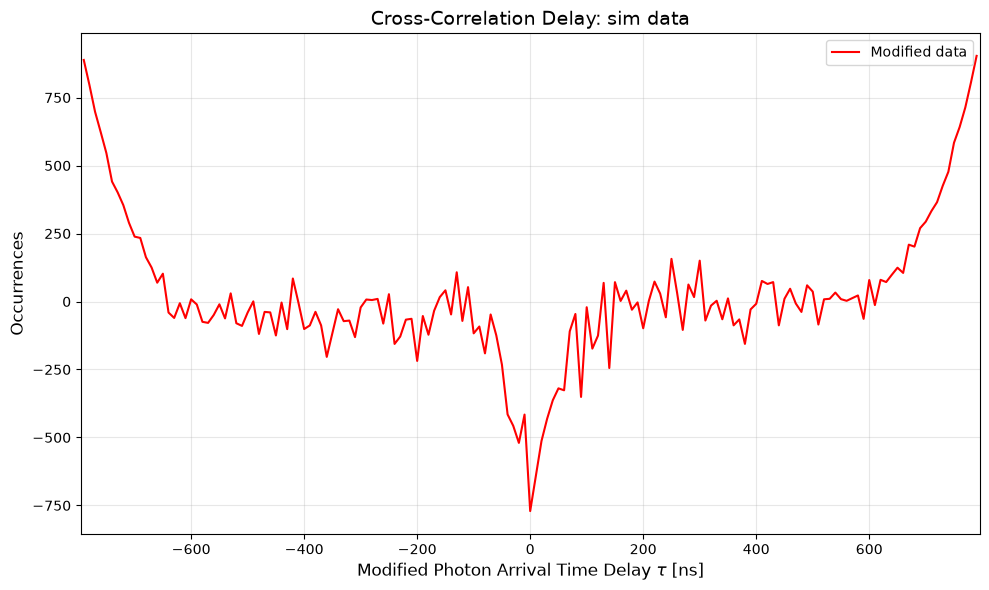

In [13]:
# Modified Data
plt.figure(figsize=(10, 6))

# 1. Calculate the background envelope for all bins simultaneously
envelope = m * np.abs(bin_centers) + c

# 2. Subtract the background envelope from the raw single-photon gaps
modified_counts = counts_single - envelope

# 3. Plot the corrected data
plt.plot(bin_centers, modified_counts, color='red', marker='', linestyle='-', label='Modified data')

plt.title('Cross-Correlation Delay: sim data', fontsize=14)
plt.xlabel(r'Modified Photon Arrival Time Delay $\tau$ [ns]', fontsize=12)
plt.ylabel('Occurrences', fontsize=12)
plt.xlim(-max_gap, max_gap + 1)
plt.legend()
plt.grid(axis='both', alpha=0.3)
plt.tight_layout()
plt.show()

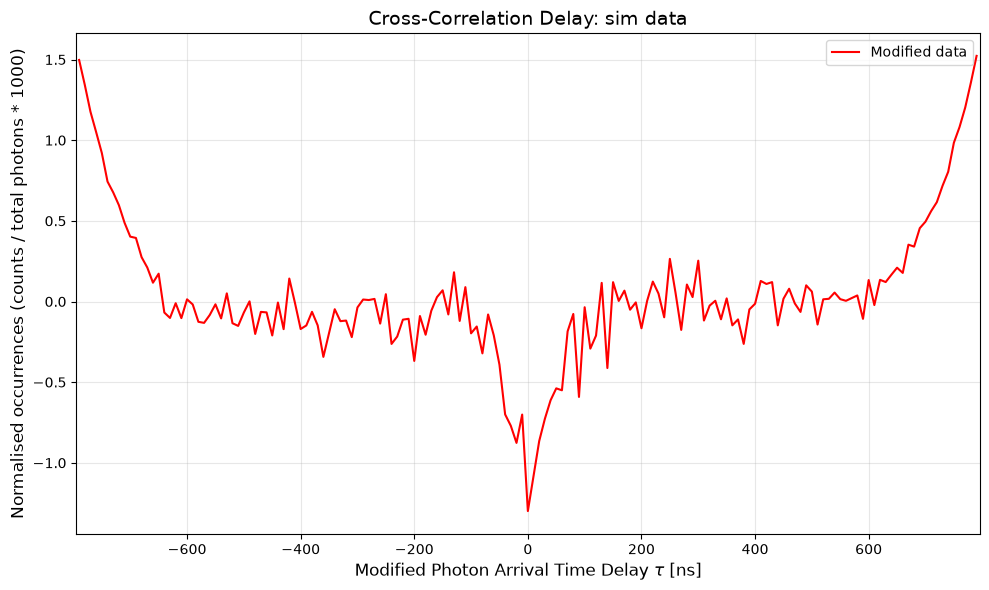

In [14]:
# Modified Data (normalised)
plt.figure(figsize=(10, 6))

# 1. Calculate the background envelope for all bins simultaneously
envelope = m * np.abs(bin_centers) + c

# 2. Subtract the background envelope from the raw single-photon gaps
modified_counts = counts_single - envelope

# 3. Normalise by total photon count
total_photons = np.sum(counts_single)
norm_modified_counts = modified_counts / total_photons * 1000

# 4. Plot the corrected, normalised data
plt.plot(bin_centers, norm_modified_counts, color='red', marker='', linestyle='-', label='Modified data')
plt.title('Cross-Correlation Delay: sim data', fontsize=14)
plt.xlabel(r'Modified Photon Arrival Time Delay $\tau$ [ns]', fontsize=12)
plt.ylabel('Normalised occurrences (counts / total photons * 1000)', fontsize=12)
plt.xlim(-max_gap, max_gap + 1)
plt.legend()
plt.grid(axis='both', alpha=0.3)
plt.tight_layout()
plt.show()